# 🌊 Sonar Signal Processing Pipeline

Simulate a basic sonar pulse-echo pipeline including waveform transmission, echo return, matched filtering, and Doppler shift.

## 🔹 1. Generate a Transmit Pulse (LFM Chirp)

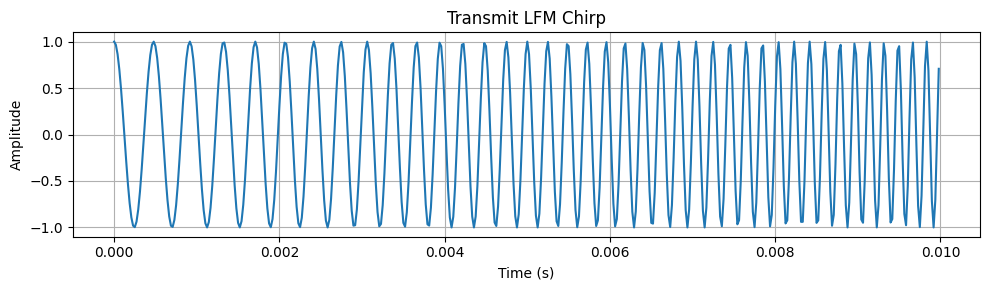

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 48000
duration = 0.01
f0, f1 = 2000, 6000
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

k = (f1 - f0) / duration
pulse = np.cos(2 * np.pi * (f0 * t + 0.5 * k * t**2))

plt.figure(figsize=(10, 3))
plt.plot(t, pulse)
plt.title("Transmit LFM Chirp")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 2. Simulate Echo from a Target at Range

In [2]:
def simulate_echo(pulse, fs, delay_sec, attenuation=0.5):
    delay_samples = int(delay_sec * fs)
    echo = np.zeros(len(pulse) + delay_samples)
    echo[delay_samples:] = attenuation * pulse
    return echo

# Simulate echo from 50 ms away (~37.5 m assuming 1500 m/s)
echo = simulate_echo(pulse, fs, delay_sec=0.05)

# Received signal = just the echo (in real case: pulse + noise + echo)
rx = echo

# Pad original pulse to match received length for correlation
pulse_padded = np.zeros_like(rx)
pulse_padded[:len(pulse)] = pulse

## 🔹 3. Matched Filter for Range Detection

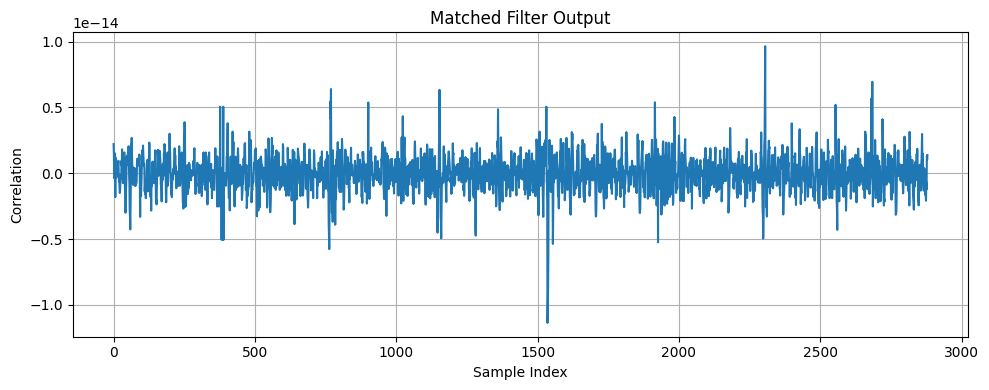

In [3]:
from scipy.signal import correlate

mf_output = correlate(rx, pulse_padded, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(mf_output)
plt.title("Matched Filter Output")
plt.xlabel("Sample Index")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 4. Simulate Doppler Shift (Moving Target)

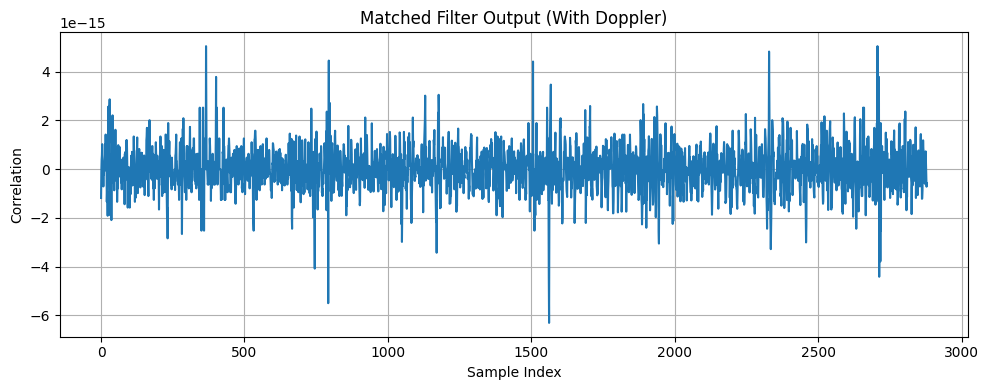

In [4]:
def apply_doppler(signal, fs, doppler_hz):
    t = np.arange(len(signal)) / fs
    return signal * np.cos(2 * np.pi * doppler_hz * t)

doppler_shift = 200  # Hz
echo_doppler = simulate_echo(apply_doppler(pulse, fs, doppler_shift), fs, delay_sec=0.05)

# Matched filtering the Doppler-affected signal
mf_output_doppler = correlate(echo_doppler, pulse_padded, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(mf_output_doppler)
plt.title("Matched Filter Output (With Doppler)")
plt.xlabel("Sample Index")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Summary
- Simulated pulse-echo sonar pipeline
- Matched filter detects echo and gives range estimate
- Doppler shift affects output response (can be further analyzed for velocity)